In [153]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

## 1. Preparing Dataset

| Data                | Definition                                                            |
|---------------------|-----------------------------------------------------------------------|
| Number              | The value currently being evaluated between 1000 and 9999 exclusively |
| Iteration           | Number of iterations required to reach the Kaprekar constant          |   
| Kaprekar's Constant | 6174                                                                  |


In [154]:
KaprekarConstant = 6174

df = pd.DataFrame()
df['Number'] = range(1000, 10000)

### Algorithm for Kaprekar's Routine

In [155]:
def kaprekar_routine(input_number: int, iteration: int, max_depth: int = 10) -> int | None:
    if iteration == 0:
        print(f'Analyzing: {input_number}')
    
    # Can't be valid in iteration 0
    if input_number == KaprekarConstant and iteration > 0:
        print('TARGET FOUND')
        return iteration
    elif max_depth == iteration or input_number == 0:
        print('TARGET NOT FOUND')
        return None
        
    ascending = int("".join(pd.Series([digit for digit in str(input_number)]).sort_values()))
    descending = int("".join(pd.Series([digit for digit in str(input_number)]).sort_values(ascending=False)))
    difference = descending - ascending

    print(f'ITERATION {iteration+1}: {descending} - {ascending} = {difference}')

    return kaprekar_routine(difference, iteration + 1, max_depth)   


### Run Kaprekar Routine

In [156]:
results: list[int|None] = []
for num in range(1000, 10000):
    results.append(kaprekar_routine(num, 0))
    print()
    
df['Iteration'] = pd.Series(results)

Analyzing: 1000
ITERATION 1: 1000 - 1 = 999
ITERATION 2: 999 - 999 = 0
TARGET NOT FOUND

Analyzing: 1001
ITERATION 1: 1100 - 11 = 1089
ITERATION 2: 9810 - 189 = 9621
ITERATION 3: 9621 - 1269 = 8352
ITERATION 4: 8532 - 2358 = 6174
TARGET FOUND

Analyzing: 1002
ITERATION 1: 2100 - 12 = 2088
ITERATION 2: 8820 - 288 = 8532
ITERATION 3: 8532 - 2358 = 6174
TARGET FOUND

Analyzing: 1003
ITERATION 1: 3100 - 13 = 3087
ITERATION 2: 8730 - 378 = 8352
ITERATION 3: 8532 - 2358 = 6174
TARGET FOUND

Analyzing: 1004
ITERATION 1: 4100 - 14 = 4086
ITERATION 2: 8640 - 468 = 8172
ITERATION 3: 8721 - 1278 = 7443
ITERATION 4: 7443 - 3447 = 3996
ITERATION 5: 9963 - 3699 = 6264
ITERATION 6: 6642 - 2466 = 4176
ITERATION 7: 7641 - 1467 = 6174
TARGET FOUND

Analyzing: 1005
ITERATION 1: 5100 - 15 = 5085
ITERATION 2: 8550 - 558 = 7992
ITERATION 3: 9972 - 2799 = 7173
ITERATION 4: 7731 - 1377 = 6354
ITERATION 5: 6543 - 3456 = 3087
ITERATION 6: 8730 - 378 = 8352
ITERATION 7: 8532 - 2358 = 6174
TARGET FOUND

Analyzing

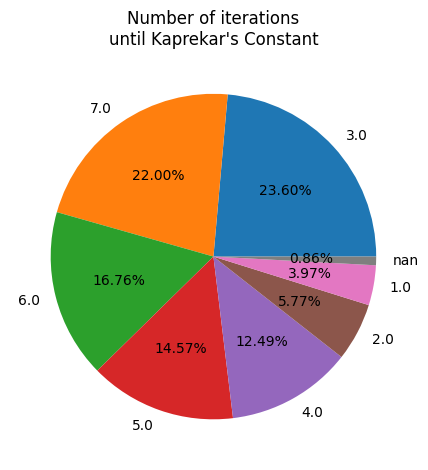

In [157]:
results = pd.DataFrame(df['Iteration'].value_counts(dropna=False))
results['count'].plot(kind='pie', title='Number of iterations\nuntil Kaprekar\'s Constant', y='count', autopct='%.2f%%')
plt.tight_layout()
